In [2]:
from google.colab import files
uploaded = files.upload()
# Upload: attention_matrices_qwen.npy, X_1b.npy, X_3b.npy, y.npy

Saving X_1b.npy to X_1b (1).npy


In [3]:
from google.colab import files
uploaded = files.upload()

Saving attention_matrices_qwen.npy to attention_matrices_qwen.npy


In [4]:
from google.colab import files
uploaded = files.upload()

Saving X_3b.npy to X_3b.npy


In [5]:
from google.colab import files
uploaded = files.upload()

Saving y.npy to y.npy


In [6]:
import numpy as np
import json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load all matrices
X_qwen = np.load('attention_matrices_qwen.npy')
X_1b   = np.load('X_1b.npy')
X_3b   = np.load('X_3b.npy')
y      = np.load('y.npy')

print("X_qwen shape:", X_qwen.shape)
print("X_1b shape:",   X_1b.shape)
print("X_3b shape:",   X_3b.shape)
print("y shape:",      y.shape)
print(" All loaded!")

X_qwen shape: (500, 28)
X_1b shape: (500, 16)
X_3b shape: (500, 28)
y shape: (500,)
 All loaded!


In [7]:
# Best layers from V1
best_qwen = 14  # 0-indexed (layer 15)
best_1b   = 10  # 0-indexed (layer 11)
best_3b   = 17  # 0-indexed (layer 18)

# Splits for each model
X_train_q, X_temp_q, y_train_q, y_temp_q = train_test_split(X_qwen, y, test_size=0.3, random_state=42, stratify=y)
X_val_q, X_test_q, y_val_q, y_test_q = train_test_split(X_temp_q, y_temp_q, test_size=0.5, random_state=42, stratify=y_temp_q)

X_train_1b, X_temp_1b, y_train_1b, y_temp_1b = train_test_split(X_1b, y, test_size=0.3, random_state=42, stratify=y)
X_val_1b, X_test_1b, y_val_1b, y_test_1b = train_test_split(X_temp_1b, y_temp_1b, test_size=0.5, random_state=42, stratify=y_temp_1b)

X_train_3b, X_temp_3b, y_train_3b, y_temp_3b = train_test_split(X_3b, y, test_size=0.3, random_state=42, stratify=y)
X_val_3b, X_test_3b, y_val_3b, y_test_3b = train_test_split(X_temp_3b, y_temp_3b, test_size=0.5, random_state=42, stratify=y_temp_3b)

results_v3_cross = {}

# Train on Llama-1B → test on Llama-3B and Qwen
clf_1b = LogisticRegression(max_iter=1000)
clf_1b.fit(X_train_1b[:, best_1b].reshape(-1,1), y_train_1b)

# Test on Llama-3B (same layer index if exists, else closest)
auroc_1b_to_3b = roc_auc_score(y_test_3b, clf_1b.predict_proba(X_test_3b[:, best_1b].reshape(-1,1))[:,1])
auroc_1b_to_3b = max(auroc_1b_to_3b, 1-auroc_1b_to_3b)

# Test on Qwen
auroc_1b_to_qwen = roc_auc_score(y_test_q, clf_1b.predict_proba(X_test_q[:, best_1b].reshape(-1,1))[:,1])
auroc_1b_to_qwen = max(auroc_1b_to_qwen, 1-auroc_1b_to_qwen)

results_v3_cross["Train_1B"] = {
    "test_on_1b": 0.8350,
    "test_on_3b": round(auroc_1b_to_3b, 4),
    "test_on_qwen": round(auroc_1b_to_qwen, 4)
}

# Train on Llama-3B → test on Llama-1B and Qwen
clf_3b = LogisticRegression(max_iter=1000)
clf_3b.fit(X_train_3b[:, best_3b].reshape(-1,1), y_train_3b)

auroc_3b_to_1b = roc_auc_score(y_test_1b, clf_3b.predict_proba(X_test_1b[:, min(best_3b, X_1b.shape[1]-1)].reshape(-1,1))[:,1])
auroc_3b_to_1b = max(auroc_3b_to_1b, 1-auroc_3b_to_1b)

auroc_3b_to_qwen = roc_auc_score(y_test_q, clf_3b.predict_proba(X_test_q[:, best_3b].reshape(-1,1))[:,1])
auroc_3b_to_qwen = max(auroc_3b_to_qwen, 1-auroc_3b_to_qwen)

results_v3_cross["Train_3B"] = {
    "test_on_3b": 0.8329,
    "test_on_1b": round(auroc_3b_to_1b, 4),
    "test_on_qwen": round(auroc_3b_to_qwen, 4)
}

# Train on Qwen → test on Llama-1B and Llama-3B
clf_qwen = LogisticRegression(max_iter=1000)
clf_qwen.fit(X_train_q[:, best_qwen].reshape(-1,1), y_train_q)

auroc_qwen_to_1b = roc_auc_score(y_test_1b, clf_qwen.predict_proba(X_test_1b[:, min(best_qwen, X_1b.shape[1]-1)].reshape(-1,1))[:,1])
auroc_qwen_to_1b = max(auroc_qwen_to_1b, 1-auroc_qwen_to_1b)

auroc_qwen_to_3b = roc_auc_score(y_test_3b, clf_qwen.predict_proba(X_test_3b[:, best_qwen].reshape(-1,1))[:,1])
auroc_qwen_to_3b = max(auroc_qwen_to_3b, 1-auroc_qwen_to_3b)

results_v3_cross["Train_Qwen"] = {
    "test_on_qwen": 0.8819,
    "test_on_1b": round(auroc_qwen_to_1b, 4),
    "test_on_3b": round(auroc_qwen_to_3b, 4)
}

print("="*55)
print("V3 Cross-Architecture Transfer Results")
print("="*55)
for train_model, results in results_v3_cross.items():
    print(f"\nTrained on {train_model}:")
    for test_model, auroc in results.items():
        print(f"  {test_model:20s}: {auroc:.4f}")

with open("v3_cross_arch_results.json", "w") as f:
    json.dump(results_v3_cross, f, indent=2)
print("\n V3 Cross-Architecture done!")

V3 Cross-Architecture Transfer Results

Trained on Train_1B:
  test_on_1b          : 0.8350
  test_on_3b          : 0.7966
  test_on_qwen        : 0.7269

Trained on Train_3B:
  test_on_3b          : 0.8329
  test_on_1b          : 0.8279
  test_on_qwen        : 0.7546

Trained on Train_Qwen:
  test_on_qwen        : 0.8819
  test_on_1b          : 0.8393
  test_on_3b          : 0.8265

 V3 Cross-Architecture done!


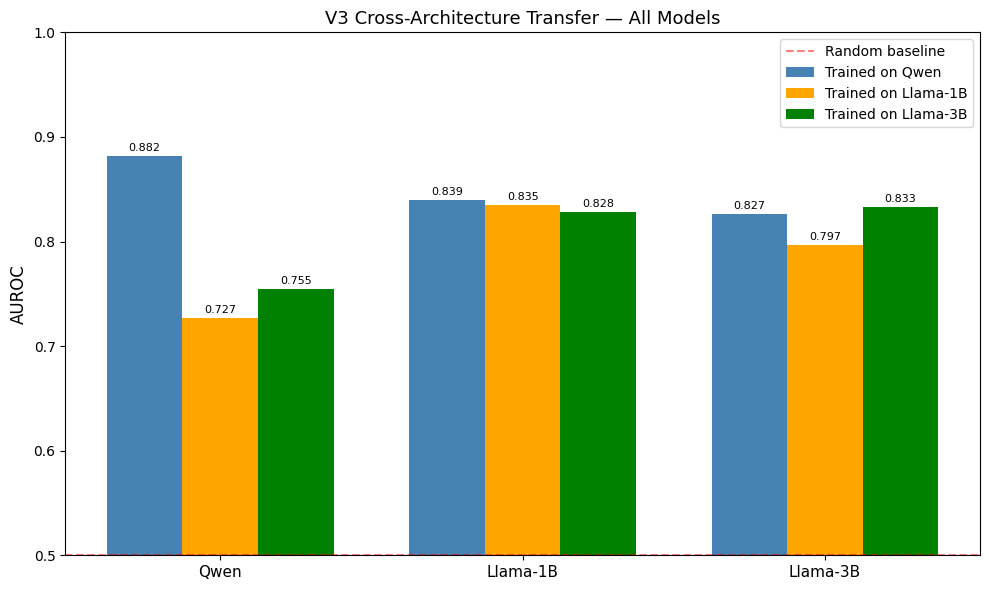

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ V3 cross-arch plot downloaded!


In [8]:
fig, ax = plt.subplots(figsize=(10,6))

models = ['Qwen', 'Llama-1B', 'Llama-3B']
train_qwen = [0.8819, 0.8393, 0.8265]
train_1b   = [0.7269, 0.8350, 0.7966]
train_3b   = [0.7546, 0.8279, 0.8329]

x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x-width, train_qwen, width, label='Trained on Qwen',     color='steelblue')
bars2 = ax.bar(x,       train_1b,   width, label='Trained on Llama-1B', color='orange')
bars3 = ax.bar(x+width, train_3b,   width, label='Trained on Llama-3B', color='green')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_title('V3 Cross-Architecture Transfer — All Models', fontsize=13)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend(fontsize=10)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('v3_cross_arch_all_models.png', dpi=150)
plt.show()

from google.colab import files
files.download('v3_cross_arch_all_models.png')
files.download('v3_cross_arch_results.json')
print("✅ V3 cross-arch plot downloaded!")